R² Score: 0.575787706032451


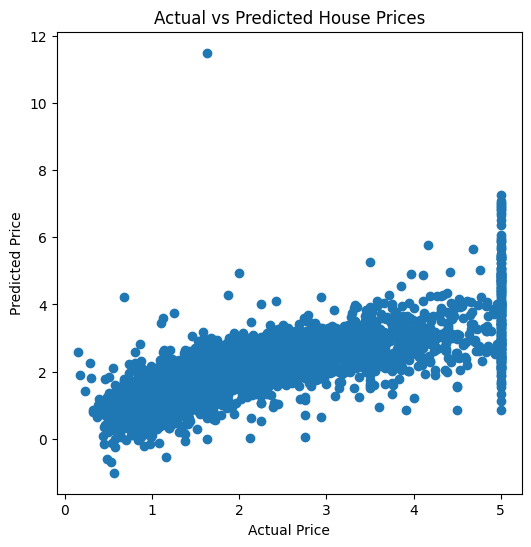

In [13]:
#ASSIGNMENT-WEEK 2
#QUESTION-1(Linear regression on housing model)

# Import Libraries
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Load Dataset
housing = fetch_california_housing()

# Create DataFrame
df = pd.DataFrame(housing.data, columns=housing.feature_names)
df['Price'] = housing.target

# Features and Target
X = df.drop('Price', axis=1)
y = df['Price']

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train Linear Regression Model
model = LinearRegression()
model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

# R² Score
print("R² Score:", r2_score(y_test, y_pred))

# Plot Predicted vs Actual
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Prices")
plt.show()




In [10]:
# Predict House Prices
y_pred = model.predict(X_test)

# Show Predicted Prices
print("Predicted House Prices:")
print(y_pred[:10])   # First 10 predicted prices

# Compare Actual vs Predicted
result = pd.DataFrame({
    "Actual Price": y_test.values,
    "Predicted Price": y_pred
})

print("\nActual vs Predicted Price:")
print(result.head(10))

Predicted House Prices:
[0.71912284 1.76401657 2.70965883 2.83892593 2.60465725 2.01175367
 2.64550005 2.16875532 2.74074644 3.91561473]

Actual vs Predicted Price:
   Actual Price  Predicted Price
0       0.47700         0.719123
1       0.45800         1.764017
2       5.00001         2.709659
3       2.18600         2.838926
4       2.78000         2.604657
5       1.58700         2.011754
6       1.98200         2.645500
7       1.57500         2.168755
8       3.40000         2.740746
9       4.46600         3.915615


#QUESTION-2(Logistic regression on titanic dataset for survival)



In [11]:
import pandas as pd
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

# Load Titanic Dataset
df = sns.load_dataset("titanic")

# Select Required Columns
df = df[['survived','pclass','sex','age','fare']]

# Fill Missing Values
df['age'].fillna(df['age'].median(), inplace=True)

# Convert Categorical Data
df['sex'] = df['sex'].map({'male':0,'female':1})

# Features and Target
X = df[['pclass','sex','age','fare']]
y = df['survived']

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train Model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

# Confusion Matrix
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.8044692737430168
Confusion Matrix:
[[90 15]
 [20 54]]


C:\Users\HP\AppData\Local\Temp\ipykernel_12844\1821112989.py:15: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['age'].fillna(df['age'].median(), inplace=True)


In [12]:
# Survival Prediction
y_pred = model.predict(X_test)

print("Predicted Survival:")
print(y_pred[:10])

# Compare Actual vs Predicted
result = pd.DataFrame({
    "Actual Survival": y_test.values,
    "Predicted Survival": y_pred
})

print("\nActual vs Predicted Survival:")
print(result.head(10))

# Accuracy
print("\nAccuracy:", accuracy_score(y_test, y_pred))

# Confusion Matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Predicted Survival:
[0 0 0 1 1 1 1 0 1 1]

Actual vs Predicted Survival:
   Actual Survival  Predicted Survival
0                1                   0
1                0                   0
2                0                   0
3                1                   1
4                1                   1
5                1                   1
6                1                   1
7                0                   0
8                1                   1
9                1                   1

Accuracy: 0.8044692737430168

Confusion Matrix:
[[90 15]
 [20 54]]
